####  CSIA6853 - Assignment 4 : Final Modeling
**Ivy Mutodi (2023721380)**

###  4.1 Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
data = pd.read_csv('final_preprocessed_dataset.csv')


In [6]:
print("Source: final_preprocessed_dataset.csv (sampled from Kaggle Sentiment Analysis for Mental Health)")
print("Language: English")
print(f"Dataset size: {data.shape[0]:,} rows, {data.shape[1]} columns")
print("\nLabels:", data['Sentiment'].unique().tolist())
print("\nClass distribution:")
print(data['Sentiment'].value_counts(normalize=True).round(4)*100)



Source: final_preprocessed_dataset.csv (sampled from Kaggle Sentiment Analysis for Mental Health)
Language: English
Dataset size: 7,000 rows, 4 columns

Labels: [0, 1, 2, 3, 4, 5, 6]

Class distribution:
Sentiment
3    31.01
2    29.24
6    20.21
0     7.29
1     5.27
5     4.93
4     2.04
Name: proportion, dtype: float64


* For the sentiments , 'Anxiety':0, 'Bipolar':1 , 'Depression': 2, 'Normal':3, 'Personality disorder':4 , 'Stress': 5, 'Suicidal': 6

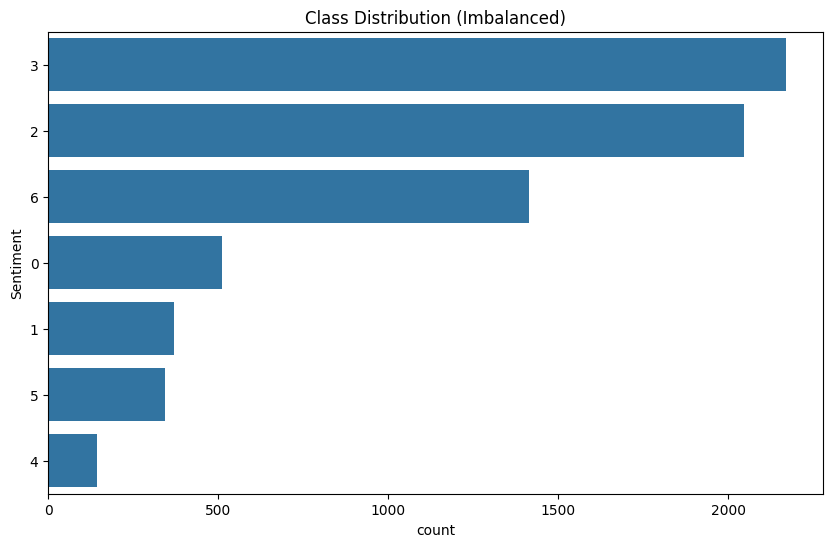

Note: Dataset is moderately imbalanced. Macro-F1 will be the primary metric.


In [10]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, y='Sentiment', order=data['Sentiment'].value_counts().index)
plt.title('Class Distribution (Imbalanced)')
plt.show()
print("Note: Dataset is moderately imbalanced. Macro-F1 will be the primary metric.")


In [11]:
data.head()

,Statement,Cleaned_tfidf,Cleaned_bert,Sentiment
0,Is this health anxiety? 1) checking temperatur...,health anxiety checking temperature time day c...,is this health anxiety checking temperature ti...,0
1,Is there any way to sleep better? I can't slee...,way sleep well cant sleep night med didnt help,is there any way to sleep better i cant sleep ...,0
2,Lamictal ? Anyone with good reviews about lami...,lamictal anyone good review lamictal,lamictal anyone with good reviews about lamictal,0
3,Has anyone tried EMDR therapy? I just started....,anyone try emdr therapy start thought like far...,has anyone tried emdr therapy i just started i...,0
4,would my may2018 ECG of picked this up? worrie...,would may ecg pick worried yesterday drill woo...,would my may ecg of picked this up worried so ...,0


### 4.2  Data preparation

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = data[['Statement', 'Cleaned_tfidf', 'Cleaned_bert']]
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples\n")


Training set size: 5600 samples
Testing set size: 1400 samples



* The text columns used from the data are Statement, Cleaned_tfidf, Cleaned_bert 
* The label is Sentiment which was already encoded from the previous notebook

In [14]:
print("Final Modeling-Ready Training Data Preview ")
train_preview = X_train.copy()
train_preview['label'] = y_train
display(train_preview.head())

Final Modeling-Ready Training Data Preview 


,Statement,Cleaned_tfidf,Cleaned_bert,label
5395,I don't want to leave my house because I know ...,dont want leave house know everyone know shes ...,i dont want to leave my house because i know t...,5
6759,I attemempted my life not even a few months ag...,attemempted life not even month ago send short...,i attemempted my life not even a few months ag...,6
4996,missykesson bet you let mcgee on there hahahaha,missykesson bet let mcgee hahahaha,missykesson bet you let mcgee on there hahahaha,3
95,Not doing well My existential OCD is so severe...,not well existential ocd severe right spend ho...,not doing well my existential ocd is so severe...,0
4037,"State I am homeless as of this morning, withou...",state homeless morning without mention title p...,state i am homeless as of this morning without...,3


* The split strategy is strictly 80/20 train test split

* note yet done with 

### 5.1 Experiment Setup
* will do it later

### 5.2 Baseline Machine Learning Models